# CORTEX MH — Task 4: Staged Multi-Modal Fusion

**Architecture:** Each modality branch pre-trains on its own dataset before fusion.

| Stage | Dataset | Branch | Label Space |
|-------|---------|--------|-------------|
| 1 | T2 CSV (text features) | Text branch | Mental state (Normal/Anxiety/Depression/Suicidal) |
| 2 | T3 CSV (clinical features) | Clinical branch | Triage P0–P3 (from tier_sim) |
| 3 | T2 + T3 merged | Full GatedFusion | Triage P0–P3 |

**Why staged?** Each branch specializes before the gate learns to combine them.
This avoids the cold-start problem where both branches start from random weights
and compete with each other during fusion training.

In [1]:
# ── Cell 1: Setup ─────────────────────────────────────────────
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import f1_score, classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

BASE   = '/content/drive/MyDrive/CORTEX'
T2_CSV = f'{BASE}/T2/task2_weak_modality_for_task4_named.csv'
T3_CSV = f'{BASE}/T3/task3_strong_modality_40k.csv'
SAVE   = f'{BASE}/T4/'
os.makedirs(SAVE, exist_ok=True)
print('Paths OK')

Device: cuda
Mounted at /content/drive
Paths OK


In [2]:
# ── Cell 2: Stage 1 — Pre-train Text Branch on T2 CSV ─────────
#
# Dataset : task2_weak_modality_for_task4_named.csv (40,012 rows)
# Features: 6 text probability features
# Labels  : task2_pred — mental state (0=Normal,1=Anxiety,2=Depression,3=Suicidal)
# Goal    : teach the text branch to recognise mental state patterns
# ──────────────────────────────────────────────────────────────

# ── Load ──────────────────────────────────────────────────────
t2 = pd.read_csv(T2_CSV)
print(f'T2 shape: {t2.shape}')
print(t2.head(2))

TEXT_FEATURES = [
    'task2_p_normal', 'task2_p_anxiety', 'task2_p_depression',
    'task2_p_suicidal', 'task2_entropy', 'task2_maxprob'
]

X_text = t2[TEXT_FEATURES].values.astype(np.float32)
y_text = t2['task2_pred'].values.astype(np.int64)

print(f'\nMental state distribution:')
for i, name in enumerate(['Normal','Anxiety','Depression','Suicidal']):
    print(f'  {i} {name}: {(y_text==i).sum():,}')

# ── Split ──────────────────────────────────────────────────────
X_tr, X_tmp, y_tr, y_tmp = train_test_split(
    X_text, y_text, test_size=0.30, stratify=y_text, random_state=SEED)
X_val, X_te, y_val, y_te = train_test_split(
    X_tmp, y_tmp, test_size=0.50, stratify=y_tmp, random_state=SEED)

# ── Scale ──────────────────────────────────────────────────────
scaler_text = StandardScaler()
X_tr  = scaler_text.fit_transform(X_tr)
X_val = scaler_text.transform(X_val)
X_te  = scaler_text.transform(X_te)

# ── Tensors + DataLoaders ──────────────────────────────────────
to_t = lambda x, y: TensorDataset(
    torch.tensor(x, dtype=torch.float32),
    torch.tensor(y, dtype=torch.long)
)
train_loader_t1 = DataLoader(to_t(X_tr,  y_tr),  batch_size=256, shuffle=True)
Xv_t1 = torch.tensor(X_val, dtype=torch.float32)
Xt_t1 = torch.tensor(X_te,  dtype=torch.float32)

# ── Class weights ──────────────────────────────────────────────
cw_t1 = compute_class_weight('balanced', classes=np.unique(y_tr), y=y_tr)
cw_t1 = torch.tensor(cw_t1, dtype=torch.float32).to(DEVICE)

# ── Model: text_proj (same as GatedModalFusion) + temp head ───
class TextBranchWithHead(nn.Module):
    def __init__(self, n_in=6, hidden=64, n_classes=4, dropout=0.3):
        super().__init__()
        self.text_proj = nn.Sequential(
            nn.Linear(n_in, hidden),
            nn.ReLU(),
            nn.Dropout(dropout)
        )
        self.head = nn.Linear(hidden, n_classes)

    def forward(self, x):
        return self.head(self.text_proj(x))

# ── Train ──────────────────────────────────────────────────────
text_model = TextBranchWithHead().to(DEVICE)
criterion1 = nn.CrossEntropyLoss(weight=cw_t1)
optimizer1 = optim.Adam(text_model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler1 = optim.lr_scheduler.StepLR(optimizer1, step_size=10, gamma=0.5)

best_f1_t1, best_state_t1 = 0.0, None
EPOCHS_S1 = 30

print('\n── Stage 1: Text Branch Pre-training ─────────────────────')
for epoch in range(1, EPOCHS_S1 + 1):
    text_model.train()
    total_loss = 0
    for xb, yb in train_loader_t1:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer1.zero_grad()
        loss = criterion1(text_model(xb), yb)
        loss.backward()
        optimizer1.step()
        total_loss += loss.item()
    scheduler1.step()

    text_model.eval()
    with torch.no_grad():
        preds = text_model(Xv_t1.to(DEVICE)).argmax(1).cpu().numpy()
    val_f1 = f1_score(y_val, preds, average='macro')
    if val_f1 > best_f1_t1:
        best_f1_t1  = val_f1
        best_state_t1 = {k: v.clone() for k, v in text_model.state_dict().items()}
    if epoch % 5 == 0:
        print(f'  Epoch {epoch:3d} | Loss: {total_loss/len(train_loader_t1):.4f} | Val Macro-F1: {val_f1:.4f}')

# ── Evaluate on test ───────────────────────────────────────────
text_model.load_state_dict(best_state_t1)
text_model.eval()
with torch.no_grad():
    te_preds = text_model(Xt_t1.to(DEVICE)).argmax(1).cpu().numpy()
print(f'\nStage 1 Best Val F1: {best_f1_t1:.4f}')
print(classification_report(y_te, te_preds,
      target_names=['Normal','Anxiety','Depression','Suicidal']))

# ── Save only text_proj weights ────────────────────────────────
text_proj_weights = {
    k.replace('text_proj.', ''): v
    for k, v in best_state_t1.items() if k.startswith('text_proj')
}
torch.save(text_proj_weights, f'{SAVE}text_branch_pretrained.pt')
print(f'Saved: {SAVE}text_branch_pretrained.pt')

T2 shape: (40012, 8)
   Unique_ID  task2_pred  task2_maxprob  task2_entropy  task2_p_normal  \
0          0           0       0.969466       0.159236        0.969466   
1          1           1       0.979821       0.115603        0.013613   

   task2_p_anxiety  task2_p_depression  task2_p_suicidal  
0         0.022684            0.004817          0.003033  
1         0.979821            0.004435          0.002131  

Mental state distribution:
  0 Normal: 16,424
  1 Anxiety: 3,836
  2 Depression: 9,788
  3 Suicidal: 9,964

── Stage 1: Text Branch Pre-training ─────────────────────
  Epoch   5 | Loss: 0.0693 | Val Macro-F1: 0.9925
  Epoch  10 | Loss: 0.0413 | Val Macro-F1: 0.9951
  Epoch  15 | Loss: 0.0346 | Val Macro-F1: 0.9965
  Epoch  20 | Loss: 0.0323 | Val Macro-F1: 0.9948
  Epoch  25 | Loss: 0.0298 | Val Macro-F1: 0.9957
  Epoch  30 | Loss: 0.0274 | Val Macro-F1: 0.9957

Stage 1 Best Val F1: 0.9967
              precision    recall  f1-score   support

      Normal       1.00    

In [3]:
# ── Cell 3: Stage 2 — Pre-train Clinical Branch on T3 CSV ──────
#
# Dataset : task3_strong_modality_40k.csv (40,012 rows)
# Features: 13 raw clinical features
# Labels  : tier_sim → P0-P3  (real Zenodo C-SSRS human annotations)
# Goal    : teach the clinical branch to map structured intake data to triage
# ──────────────────────────────────────────────────────────────

# ── Load ──────────────────────────────────────────────────────
t3 = pd.read_csv(T3_CSV)
print(f'T3 shape: {t3.shape}')
print(t3.head(2))

CLINICAL_FEATURES = [
    'I_present', 'I_severity_level', 'I_freq', 'I_duration',
    'I_controllability', 'I_deterrents', 'I_reasons',
    'B_preparatory', 'B_aborted', 'B_interrupted', 'B_actual_attempt',
    'days_since_last_event', 'duration_since_onset'
]

# ── Label assignment: tier_sim → P0-P3 ────────────────────────
def assign_triage_from_tier(tier):
    if tier == 4:       return 0  # P0 — Attempt (Critical)
    elif tier == 3:     return 1  # P1 — Behavior (High)
    elif tier == 2:     return 2  # P2 — Ideation (Moderate)
    else:               return 3  # P3 — Indicator/Supportive (Low)

t3['triage_enc'] = t3['tier_sim'].apply(assign_triage_from_tier)

print(f'\nTriage distribution:')
for i, name in enumerate(['P0','P1','P2','P3']):
    print(f'  {name}: {(t3.triage_enc==i).sum():,}')

X_clin = t3[CLINICAL_FEATURES].values.astype(np.float32)
y_clin = t3['triage_enc'].values.astype(np.int64)

# ── Split ──────────────────────────────────────────────────────
Xc_tr, Xc_tmp, yc_tr, yc_tmp = train_test_split(
    X_clin, y_clin, test_size=0.30, stratify=y_clin, random_state=SEED)
Xc_val, Xc_te, yc_val, yc_te = train_test_split(
    Xc_tmp, yc_tmp, test_size=0.50, stratify=yc_tmp, random_state=SEED)

# ── Scale ──────────────────────────────────────────────────────
scaler_clin = StandardScaler()
Xc_tr  = scaler_clin.fit_transform(Xc_tr)
Xc_val = scaler_clin.transform(Xc_val)
Xc_te  = scaler_clin.transform(Xc_te)

# ── Tensors ────────────────────────────────────────────────────
train_loader_s2 = DataLoader(
    TensorDataset(torch.tensor(Xc_tr, dtype=torch.float32),
                  torch.tensor(yc_tr, dtype=torch.long)),
    batch_size=256, shuffle=True)
Xv_s2 = torch.tensor(Xc_val, dtype=torch.float32)
Xt_s2 = torch.tensor(Xc_te,  dtype=torch.float32)

# ── Class weights ──────────────────────────────────────────────
cw_s2 = compute_class_weight('balanced', classes=np.unique(yc_tr), y=yc_tr)
cw_s2 = torch.tensor(cw_s2, dtype=torch.float32).to(DEVICE)

# ── Model: clinical_proj + temp head ──────────────────────────
class ClinicalBranchWithHead(nn.Module):
    def __init__(self, n_in=13, hidden=64, n_classes=4, dropout=0.3):
        super().__init__()
        self.clinical_proj = nn.Sequential(
            nn.Linear(n_in, hidden),
            nn.ReLU(),
            nn.Dropout(dropout)
        )
        self.head = nn.Linear(hidden, n_classes)

    def forward(self, x):
        return self.head(self.clinical_proj(x))

# ── Train ──────────────────────────────────────────────────────
clin_model = ClinicalBranchWithHead().to(DEVICE)
criterion2 = nn.CrossEntropyLoss(weight=cw_s2)
optimizer2 = optim.Adam(clin_model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler2 = optim.lr_scheduler.StepLR(optimizer2, step_size=10, gamma=0.5)

best_f1_s2, best_state_s2 = 0.0, None
EPOCHS_S2 = 30

print('\n── Stage 2: Clinical Branch Pre-training ─────────────────')
for epoch in range(1, EPOCHS_S2 + 1):
    clin_model.train()
    total_loss = 0
    for xb, yb in train_loader_s2:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer2.zero_grad()
        loss = criterion2(clin_model(xb), yb)
        loss.backward()
        optimizer2.step()
        total_loss += loss.item()
    scheduler2.step()

    clin_model.eval()
    with torch.no_grad():
        preds = clin_model(Xv_s2.to(DEVICE)).argmax(1).cpu().numpy()
    val_f1 = f1_score(yc_val, preds, average='macro')
    if val_f1 > best_f1_s2:
        best_f1_s2    = val_f1
        best_state_s2 = {k: v.clone() for k, v in clin_model.state_dict().items()}
    if epoch % 5 == 0:
        print(f'  Epoch {epoch:3d} | Loss: {total_loss/len(train_loader_s2):.4f} | Val Macro-F1: {val_f1:.4f}')

# ── Evaluate ───────────────────────────────────────────────────
clin_model.load_state_dict(best_state_s2)
clin_model.eval()
with torch.no_grad():
    te_preds_s2 = clin_model(Xt_s2.to(DEVICE)).argmax(1).cpu().numpy()
print(f'\nStage 2 Best Val F1: {best_f1_s2:.4f}')
print(classification_report(yc_te, te_preds_s2, target_names=['P0','P1','P2','P3']))

# ── Save only clinical_proj weights ───────────────────────────
clin_proj_weights = {
    k.replace('clinical_proj.', ''): v
    for k, v in best_state_s2.items() if k.startswith('clinical_proj')
}
torch.save(clin_proj_weights, f'{SAVE}clinical_branch_pretrained.pt')
print(f'Saved: {SAVE}clinical_branch_pretrained.pt')

T3 shape: (40012, 25)
   Unique_ID age_group  tier_sim  I_present  I_severity_level  I_freq  \
0          0     Adult         0          0                 0       0   
1          1      Teen         1          0                 0       0   

   I_duration  I_controllability  I_deterrents  I_reasons  ...  \
0           0                  0             0          0  ...   
1           0                  0             0          0  ...   

   days_since_last_event  duration_since_onset  points_behavior  \
0                      0                     0              0.0   
1                      0                     0              0.0   

   points_ideation  points_intensity  points_acute  points_persistence  \
0              0.0               0.0           0.0                 0.0   
1              0.0               0.0           0.0                 0.0   

   points_temporal  severity_score_rule  risk_band  
0              0.0                  0.0        Low  
1              0.0          

In [4]:
# ── Cell 4: Stage 3 Setup — Merge + Features + Split ──────────

# ── Merge T2 + T3 on Unique_ID ─────────────────────────────────
df = pd.merge(t2, t3, on='Unique_ID', how='inner')
print(f'Merged shape: {df.shape}')

# ── Triage labels (from tier_sim, same as Stage 2) ─────────────
df['triage_enc'] = df['tier_sim'].apply(assign_triage_from_tier)
print('\nTriage distribution (merged):')
print(df['triage_enc'].value_counts().sort_index())

# ── All 19 training features (NO leakage columns) ─────────────
ALL_FEATURES = TEXT_FEATURES + CLINICAL_FEATURES   # 6 + 13 = 19
N_TEXT     = len(TEXT_FEATURES)    # 6
N_CLINICAL = len(CLINICAL_FEATURES)  # 13

X_all = df[ALL_FEATURES].values.astype(np.float32)
y_all = df['triage_enc'].values.astype(np.int64)

# ── Split 70 / 15 / 15 ────────────────────────────────────────
X_tr3, X_tmp3, y_tr3, y_tmp3 = train_test_split(
    X_all, y_all, test_size=0.30, stratify=y_all, random_state=SEED)
X_val3, X_te3, y_val3, y_te3 = train_test_split(
    X_tmp3, y_tmp3, test_size=0.50, stratify=y_tmp3, random_state=SEED)

print(f'\nTrain: {len(X_tr3):,} | Val: {len(X_val3):,} | Test: {len(X_te3):,}')

# ── Scale all 19 features together ────────────────────────────
scaler_all = StandardScaler()
X_tr3  = scaler_all.fit_transform(X_tr3)
X_val3 = scaler_all.transform(X_val3)
X_te3  = scaler_all.transform(X_te3)

# ── Split into text / clinical slices ─────────────────────────
Xt_tr3,  Xc_tr3  = X_tr3[:, :N_TEXT],  X_tr3[:, N_TEXT:]
Xt_val3, Xc_val3 = X_val3[:, :N_TEXT], X_val3[:, N_TEXT:]
Xt_te3,  Xc_te3  = X_te3[:, :N_TEXT],  X_te3[:, N_TEXT:]

# ── Tensors ────────────────────────────────────────────────────
train_ds3 = TensorDataset(
    torch.tensor(Xt_tr3,  dtype=torch.float32),
    torch.tensor(Xc_tr3,  dtype=torch.float32),
    torch.tensor(y_tr3,   dtype=torch.long))
train_loader3 = DataLoader(train_ds3, batch_size=256, shuffle=True)

Xt_v3 = torch.tensor(Xt_val3, dtype=torch.float32)
Xc_v3 = torch.tensor(Xc_val3, dtype=torch.float32)
Xt_e3 = torch.tensor(Xt_te3,  dtype=torch.float32)
Xc_e3 = torch.tensor(Xc_te3,  dtype=torch.float32)

# ── Class weights ──────────────────────────────────────────────
cw_s3 = compute_class_weight('balanced', classes=np.unique(y_tr3), y=y_tr3)
cw_s3_t = torch.tensor(cw_s3, dtype=torch.float32).to(DEVICE)

print('Stage 3 setup complete.')

Merged shape: (40012, 33)

Triage distribution (merged):
triage_enc
0     6728
1     3947
2     8101
3    21236
Name: count, dtype: int64

Train: 28,008 | Val: 6,002 | Test: 6,002
Stage 3 setup complete.


In [5]:
# ── Cell 5: GatedModalFusion Class + Weight Loading ────────────

class GatedModalFusion(nn.Module):
    def __init__(self, n_text=6, n_clinical=13, hidden_dim=64, n_classes=4, dropout=0.3):
        super().__init__()

        self.text_proj = nn.Sequential(
            nn.Linear(n_text, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout)
        )
        self.clinical_proj = nn.Sequential(
            nn.Linear(n_clinical, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout)
        )
        # Gate: takes raw concat of both modalities → scalar alpha
        self.gate = nn.Sequential(
            nn.Linear(n_text + n_clinical, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1),
            nn.Sigmoid()   # alpha in [0,1]; 1 = trust clinical, 0 = trust text
        )
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, n_classes)
        )

    def forward(self, x_text, x_clinical):
        h_text     = self.text_proj(x_text)
        h_clinical = self.clinical_proj(x_clinical)
        x_concat   = torch.cat([x_text, x_clinical], dim=1)
        alpha      = self.gate(x_concat)             # (batch, 1)
        h_fused    = alpha * h_clinical + (1 - alpha) * h_text
        logits     = self.classifier(h_fused)
        return logits, alpha


# ── Instantiate and load pretrained branch weights ─────────────
fusion_model = GatedModalFusion(
    n_text=N_TEXT, n_clinical=N_CLINICAL, hidden_dim=64, n_classes=4
).to(DEVICE)

# Load Stage 1 weights into text_proj
text_w = torch.load(f'{SAVE}text_branch_pretrained.pt', map_location=DEVICE)
fusion_model.text_proj.load_state_dict(text_w)
print('Loaded text_proj from Stage 1 checkpoint.')

# Load Stage 2 weights into clinical_proj
clin_w = torch.load(f'{SAVE}clinical_branch_pretrained.pt', map_location=DEVICE)
fusion_model.clinical_proj.load_state_dict(clin_w)
print('Loaded clinical_proj from Stage 2 checkpoint.')

criterion3 = nn.CrossEntropyLoss(weight=cw_s3_t)

Loaded text_proj from Stage 1 checkpoint.
Loaded clinical_proj from Stage 2 checkpoint.


In [6]:
# ── Cell 6: Stage 3 Phase A — Freeze Branches, Train Gate + Classifier ──
#
# Branches start from pre-trained weights (Stages 1 & 2).
# Phase A: keep them frozen so the gate and classifier learn
#          to fuse the already-specialized representations
#          before any fine-tuning disturbs the branch weights.
# ──────────────────────────────────────────────────────────────

def freeze_branches(model):
    for p in model.text_proj.parameters():     p.requires_grad = False
    for p in model.clinical_proj.parameters(): p.requires_grad = False

def unfreeze_branches(model):
    for p in model.text_proj.parameters():     p.requires_grad = True
    for p in model.clinical_proj.parameters(): p.requires_grad = True

def run_epoch(model, loader, optimizer, criterion, train=True):
    model.train() if train else model.eval()
    total_loss = 0
    with torch.set_grad_enabled(train):
        for xt, xc, yb in loader:
            xt, xc, yb = xt.to(DEVICE), xc.to(DEVICE), yb.to(DEVICE)
            if train: optimizer.zero_grad()
            logits, _ = model(xt, xc)
            loss = criterion(logits, yb)
            if train:
                loss.backward()
                optimizer.step()
            total_loss += loss.item()
    return total_loss / len(loader)

def eval_val(model):
    model.eval()
    with torch.no_grad():
        logits, alpha = model(Xt_v3.to(DEVICE), Xc_v3.to(DEVICE))
        preds = logits.argmax(1).cpu().numpy()
    return f1_score(y_val3, preds, average='macro'), alpha.cpu().numpy()

# ── Phase A: freeze branches ───────────────────────────────────
freeze_branches(fusion_model)

opt_A = optim.Adam(
    filter(lambda p: p.requires_grad, fusion_model.parameters()),
    lr=1e-3, weight_decay=1e-4
)
sch_A = optim.lr_scheduler.StepLR(opt_A, step_size=5, gamma=0.5)

best_f1_s3, best_state_s3 = 0.0, None
EPOCHS_PHASE_A = 10

print('── Phase A (branches frozen, epochs 1–10) ────────────────')
for epoch in range(1, EPOCHS_PHASE_A + 1):
    loss = run_epoch(fusion_model, train_loader3, opt_A, criterion3, train=True)
    sch_A.step()
    val_f1, _ = eval_val(fusion_model)
    if val_f1 > best_f1_s3:
        best_f1_s3    = val_f1
        best_state_s3 = {k: v.clone() for k, v in fusion_model.state_dict().items()}
    print(f'  Epoch {epoch:3d} | Loss: {loss:.4f} | Val Macro-F1: {val_f1:.4f}')

print(f'\nPhase A best Val F1: {best_f1_s3:.4f}')

── Phase A (branches frozen, epochs 1–10) ────────────────
  Epoch   1 | Loss: 0.6323 | Val Macro-F1: 0.9399
  Epoch   2 | Loss: 0.1783 | Val Macro-F1: 0.9613
  Epoch   3 | Loss: 0.1389 | Val Macro-F1: 0.9631
  Epoch   4 | Loss: 0.1267 | Val Macro-F1: 0.9637
  Epoch   5 | Loss: 0.1142 | Val Macro-F1: 0.9663
  Epoch   6 | Loss: 0.1115 | Val Macro-F1: 0.9669
  Epoch   7 | Loss: 0.1070 | Val Macro-F1: 0.9667
  Epoch   8 | Loss: 0.1056 | Val Macro-F1: 0.9681
  Epoch   9 | Loss: 0.1036 | Val Macro-F1: 0.9678
  Epoch  10 | Loss: 0.1028 | Val Macro-F1: 0.9670

Phase A best Val F1: 0.9681


── Phase B (all unfrozen, epochs 11–50) ─────────────────
  Epoch  15 | Loss: 0.0885 | Val Macro-F1: 0.9717
  Epoch  20 | Loss: 0.0866 | Val Macro-F1: 0.9729
  Epoch  25 | Loss: 0.0849 | Val Macro-F1: 0.9722
  Epoch  30 | Loss: 0.0836 | Val Macro-F1: 0.9714
  Epoch  35 | Loss: 0.0820 | Val Macro-F1: 0.9723
  Epoch  40 | Loss: 0.0815 | Val Macro-F1: 0.9719
  Epoch  45 | Loss: 0.0816 | Val Macro-F1: 0.9726
  Epoch  50 | Loss: 0.0826 | Val Macro-F1: 0.9715

Stage 3 Best Val F1: 0.9732


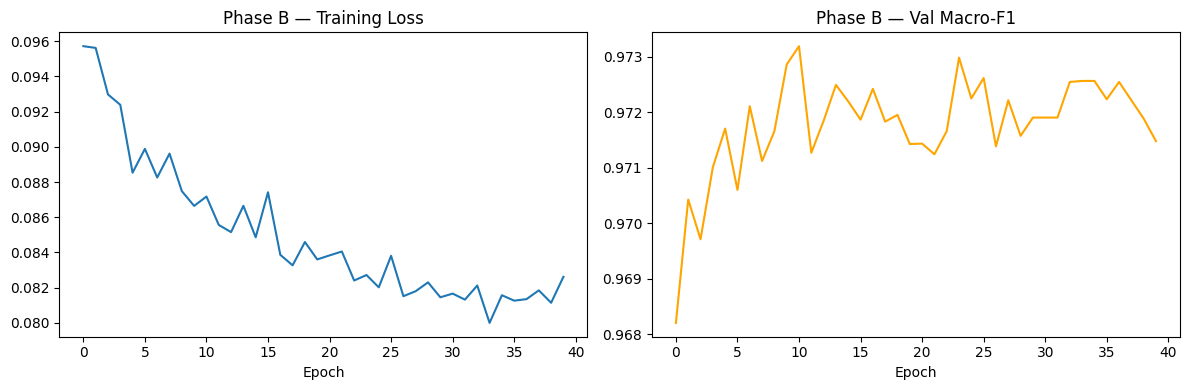

Saved: t4_staged_training_curves.png


In [7]:
# ── Cell 7: Stage 3 Phase B — Unfreeze, Fine-tune End-to-End ──
#
# Now that the gate and classifier have warm-started,
# unfreeze the branches and fine-tune everything.
# Use a LOWER learning rate for the branches to avoid
# overwriting the specialized representations from Stages 1 & 2.
# ──────────────────────────────────────────────────────────────

unfreeze_branches(fusion_model)

opt_B = optim.Adam([
    {'params': fusion_model.gate.parameters(),         'lr': 1e-3},
    {'params': fusion_model.classifier.parameters(),   'lr': 1e-3},
    {'params': fusion_model.text_proj.parameters(),    'lr': 1e-4},  # pretrained — lower LR
    {'params': fusion_model.clinical_proj.parameters(),'lr': 1e-4},  # pretrained — lower LR
], weight_decay=1e-4)
sch_B = optim.lr_scheduler.StepLR(opt_B, step_size=10, gamma=0.5)

EPOCHS_PHASE_B = 40
train_losses_B, val_f1s_B = [], []

print('── Phase B (all unfrozen, epochs 11–50) ─────────────────')
for epoch in range(1, EPOCHS_PHASE_B + 1):
    loss = run_epoch(fusion_model, train_loader3, opt_B, criterion3, train=True)
    sch_B.step()
    val_f1, _ = eval_val(fusion_model)
    train_losses_B.append(loss)
    val_f1s_B.append(val_f1)
    if val_f1 > best_f1_s3:
        best_f1_s3    = val_f1
        best_state_s3 = {k: v.clone() for k, v in fusion_model.state_dict().items()}
    if epoch % 5 == 0:
        print(f'  Epoch {epoch+EPOCHS_PHASE_A:3d} | Loss: {loss:.4f} | Val Macro-F1: {val_f1:.4f}')

fusion_model.load_state_dict(best_state_s3)
print(f'\nStage 3 Best Val F1: {best_f1_s3:.4f}')

# ── Training curves ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(train_losses_B, label='Train Loss')
axes[0].set_title('Phase B — Training Loss'); axes[0].set_xlabel('Epoch')
axes[1].plot(val_f1s_B, label='Val Macro-F1', color='orange')
axes[1].set_title('Phase B — Val Macro-F1'); axes[1].set_xlabel('Epoch')
plt.tight_layout()
plt.savefig(f'{SAVE}t4_staged_training_curves.png', dpi=150)
plt.show()
print(f'Saved: t4_staged_training_curves.png')

── Test Set Evaluation ───────────────────────────────────
               precision    recall  f1-score   support

P0 (Critical)       0.96      0.99      0.97      1010
    P1 (High)       0.96      0.92      0.94       592
P2 (Moderate)       0.97      1.00      0.98      1215
     P3 (Low)       1.00      0.98      0.99      3185

     accuracy                           0.98      6002
    macro avg       0.97      0.97      0.97      6002
 weighted avg       0.98      0.98      0.98      6002

Macro F1   : 0.9724
P0 Recall  : 0.9921  (mission-critical)
P1 Recall  : 0.9223  (mission-critical)
Mean alpha : 0.9436  (1=trust clinical, 0=trust text)


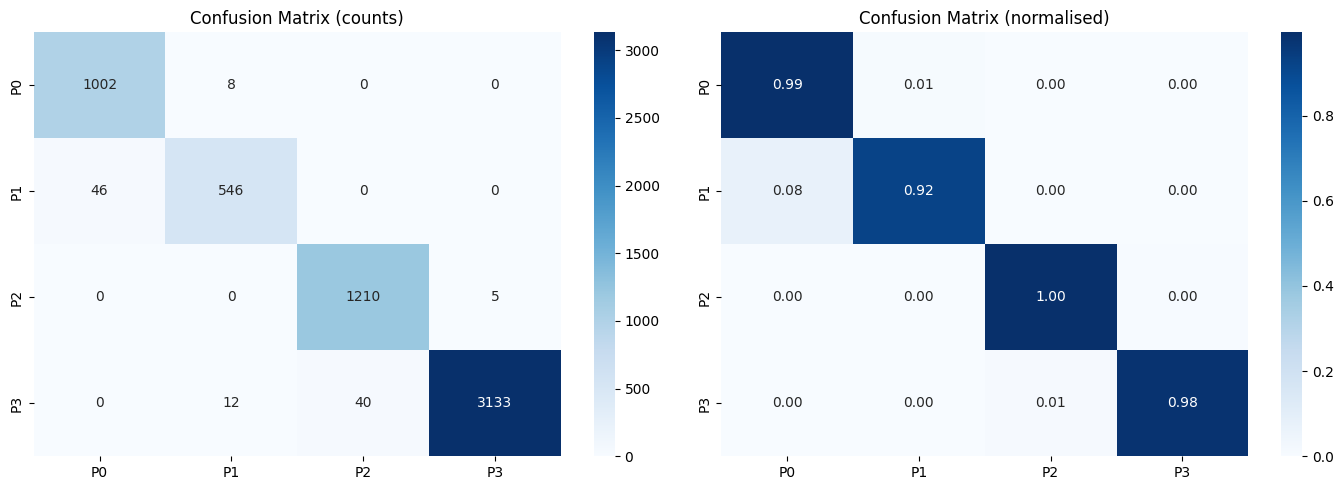

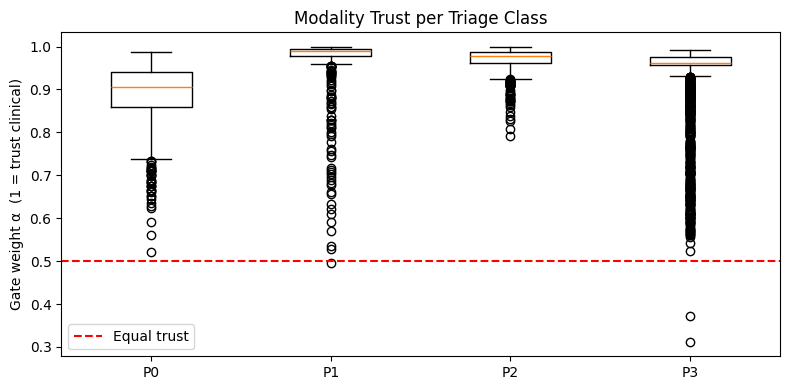


α > 0.5 → model trusts clinical more | α < 0.5 → trusts text more


In [8]:
# ── Cell 8: Evaluation ─────────────────────────────────────────

fusion_model.eval()
with torch.no_grad():
    test_logits, test_alpha = fusion_model(Xt_e3.to(DEVICE), Xc_e3.to(DEVICE))
test_preds = test_logits.argmax(1).cpu().numpy()
test_probs = torch.softmax(test_logits, dim=1).cpu().numpy()
test_alpha_np = test_alpha.cpu().numpy().flatten()

TRIAGE_NAMES = ['P0 (Critical)', 'P1 (High)', 'P2 (Moderate)', 'P3 (Low)']

print('── Test Set Evaluation ───────────────────────────────────')
print(classification_report(y_te3, test_preds, target_names=TRIAGE_NAMES))

macro_f1  = f1_score(y_te3, test_preds, average='macro')
p0_recall = (test_preds[y_te3 == 0] == 0).mean()
p1_recall = (test_preds[y_te3 == 1] == 1).mean()
print(f'Macro F1   : {macro_f1:.4f}')
print(f'P0 Recall  : {p0_recall:.4f}  (mission-critical)')
print(f'P1 Recall  : {p1_recall:.4f}  (mission-critical)')
print(f'Mean alpha : {test_alpha_np.mean():.4f}  (1=trust clinical, 0=trust text)')

# ── Confusion Matrix ───────────────────────────────────────────
cm = confusion_matrix(y_te3, test_preds)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(cm,      annot=True, fmt='d',    ax=axes[0], cmap='Blues',
            xticklabels=['P0','P1','P2','P3'], yticklabels=['P0','P1','P2','P3'])
axes[0].set_title('Confusion Matrix (counts)')
sns.heatmap(cm_norm, annot=True, fmt='.2f',  ax=axes[1], cmap='Blues',
            xticklabels=['P0','P1','P2','P3'], yticklabels=['P0','P1','P2','P3'])
axes[1].set_title('Confusion Matrix (normalised)')
plt.tight_layout()
plt.savefig(f'{SAVE}t4_staged_confusion_matrix.png', dpi=150)
plt.show()

# ── Gate weight alpha by triage class ─────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
data_alpha = [test_alpha_np[y_te3 == i] for i in range(4)]
ax.boxplot(data_alpha, labels=['P0','P1','P2','P3'])
ax.set_ylabel('Gate weight α  (1 = trust clinical)')
ax.set_title('Modality Trust per Triage Class')
ax.axhline(0.5, color='red', linestyle='--', label='Equal trust')
ax.legend()
plt.tight_layout()
plt.savefig(f'{SAVE}t4_staged_gate_weights.png', dpi=150)
plt.show()
print('\nα > 0.5 → model trusts clinical more | α < 0.5 → trusts text more')

      Model  Macro-F1  P0 Recall  P1 Recall  ΔF1 vs Full
 Full Model    0.9724     0.9921     0.9223       0.0000
    No Text    0.9703     1.0000     0.9037      -0.0021
No Clinical    0.1733     0.0000     0.0000      -0.7991
No Temporal    0.9712     0.9921     0.9189      -0.0012


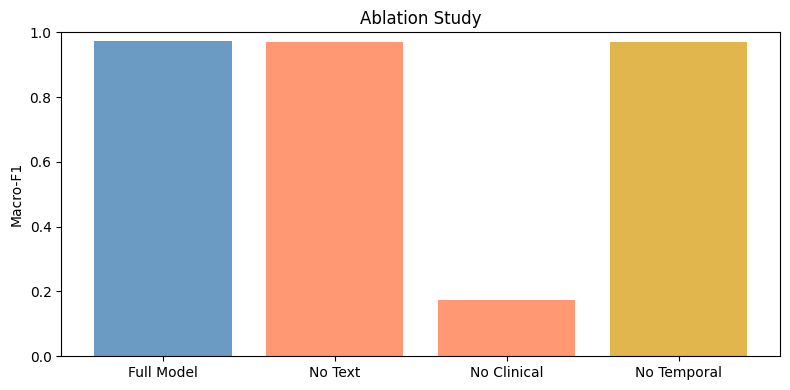

In [9]:
# ── Cell 9: Ablation Study ─────────────────────────────────────
#
# Three ablation variants trained with the SAME staged approach:
#   No Text     — zero out columns 0-5 (text features)
#   No Clinical — zero out columns 6-18 (clinical features)
#   No Temporal — zero out days_since_last_event + duration_since_onset
# ──────────────────────────────────────────────────────────────

TEMPORAL_IDX = [
    ALL_FEATURES.index('days_since_last_event'),
    ALL_FEATURES.index('duration_since_onset')
]

def ablation_inference(model, Xt, Xc, zero_text=False, zero_clin=False, zero_temporal=False):
    Xt_ = Xt.clone()
    Xc_ = Xc.clone()
    if zero_text:     Xt_[:] = 0
    if zero_clin:     Xc_[:] = 0
    if zero_temporal:
        # temporal cols are at position N_TEXT + (index in CLINICAL_FEATURES)
        t_clin_idx = [CLINICAL_FEATURES.index('days_since_last_event'),
                      CLINICAL_FEATURES.index('duration_since_onset')]
        Xc_[:, t_clin_idx] = 0
    model.eval()
    with torch.no_grad():
        logits, _ = model(Xt_.to(DEVICE), Xc_.to(DEVICE))
    return logits.argmax(1).cpu().numpy()

ablation_results = []
configs = [
    ('Full Model',   dict(zero_text=False, zero_clin=False, zero_temporal=False)),
    ('No Text',      dict(zero_text=True,  zero_clin=False, zero_temporal=False)),
    ('No Clinical',  dict(zero_text=False, zero_clin=True,  zero_temporal=False)),
    ('No Temporal',  dict(zero_text=False, zero_clin=False, zero_temporal=True)),
]

for name, kwargs in configs:
    preds = ablation_inference(fusion_model, Xt_e3, Xc_e3, **kwargs)
    mf1   = f1_score(y_te3, preds, average='macro')
    p0r   = (preds[y_te3 == 0] == 0).mean() if (y_te3 == 0).sum() > 0 else 0
    p1r   = (preds[y_te3 == 1] == 1).mean() if (y_te3 == 1).sum() > 0 else 0
    ablation_results.append({'Model': name, 'Macro-F1': round(mf1,4),
                             'P0 Recall': round(p0r,4), 'P1 Recall': round(p1r,4)})

abl_df = pd.DataFrame(ablation_results)
abl_df['ΔF1 vs Full'] = (abl_df['Macro-F1'] - abl_df.loc[0,'Macro-F1']).round(4)
print(abl_df.to_string(index=False))

# ── Save ablation table ────────────────────────────────────────
abl_df.to_csv(f'{SAVE}t4_staged_ablation_results.csv', index=False)

fig, ax = plt.subplots(figsize=(8, 4))
x = range(len(abl_df))
ax.bar(x, abl_df['Macro-F1'], color=['steelblue','coral','coral','goldenrod'], alpha=0.8)
ax.set_xticks(x); ax.set_xticklabels(abl_df['Model'])
ax.set_ylabel('Macro-F1'); ax.set_title('Ablation Study')
ax.set_ylim(0, 1)
plt.tight_layout()
plt.savefig(f'{SAVE}t4_staged_ablation.png', dpi=150)
plt.show()

In [10]:
# ── Cell 10: Export All Artifacts ─────────────────────────────

import json

# ── Model checkpoint ──────────────────────────────────────────
torch.save({
    'model_state_dict': best_state_s3,
    'scaler_mean':      scaler_all.mean_.tolist(),
    'scaler_scale':     scaler_all.scale_.tolist(),
    'text_features':    TEXT_FEATURES,
    'clinical_features': CLINICAL_FEATURES,
    'n_text':           N_TEXT,
    'n_clinical':       N_CLINICAL,
}, f'{SAVE}t4_gated_fusion_staged.pt')

# ── Test predictions CSV ───────────────────────────────────────
pred_df = pd.DataFrame({
    'true_label':    y_te3,
    'pred_label':    test_preds,
    'correct':       (y_te3 == test_preds).astype(int),
    'confidence':    test_probs.max(axis=1),
    'alpha':         test_alpha_np,
    'prob_P0':       test_probs[:, 0],
    'prob_P1':       test_probs[:, 1],
    'prob_P2':       test_probs[:, 2],
    'prob_P3':       test_probs[:, 3],
})
pred_df.to_csv(f'{SAVE}t4_staged_test_predictions.csv', index=False)

# ── Evaluation report JSON ────────────────────────────────────
report = {
    'stage1_text_branch':     {'best_val_f1': round(best_f1_t1, 4)},
    'stage2_clinical_branch': {'best_val_f1': round(best_f1_s2, 4)},
    'stage3_fusion': {
        'best_val_f1':  round(best_f1_s3, 4),
        'test_macro_f1': round(macro_f1, 4),
        'p0_recall':    round(float(p0_recall), 4),
        'p1_recall':    round(float(p1_recall), 4),
        'mean_alpha':   round(float(test_alpha_np.mean()), 4),
        'alpha_by_class': {
            f'P{i}': round(float(test_alpha_np[y_te3 == i].mean()), 4)
            for i in range(4)
        }
    },
    'ablation': abl_df.to_dict(orient='records'),
}
with open(f'{SAVE}t4_staged_evaluation_report.json', 'w') as f:
    json.dump(report, f, indent=2)

print('── All artifacts saved ────────────────────────────────────')
artifacts = [
    't4_gated_fusion_staged.pt',
    'text_branch_pretrained.pt',
    'clinical_branch_pretrained.pt',
    't4_staged_test_predictions.csv',
    't4_staged_ablation_results.csv',
    't4_staged_evaluation_report.json',
    't4_staged_training_curves.png',
    't4_staged_confusion_matrix.png',
    't4_staged_gate_weights.png',
    't4_staged_ablation.png',
]
for a in artifacts:
    print(f'  {SAVE}{a}')
print('\nDone.')

── All artifacts saved ────────────────────────────────────
  /content/drive/MyDrive/CORTEX/T4/t4_gated_fusion_staged.pt
  /content/drive/MyDrive/CORTEX/T4/text_branch_pretrained.pt
  /content/drive/MyDrive/CORTEX/T4/clinical_branch_pretrained.pt
  /content/drive/MyDrive/CORTEX/T4/t4_staged_test_predictions.csv
  /content/drive/MyDrive/CORTEX/T4/t4_staged_ablation_results.csv
  /content/drive/MyDrive/CORTEX/T4/t4_staged_evaluation_report.json
  /content/drive/MyDrive/CORTEX/T4/t4_staged_training_curves.png
  /content/drive/MyDrive/CORTEX/T4/t4_staged_confusion_matrix.png
  /content/drive/MyDrive/CORTEX/T4/t4_staged_gate_weights.png
  /content/drive/MyDrive/CORTEX/T4/t4_staged_ablation.png

Done.
